# EDA 02 — Categorical Features

Analyse each categorical column: value distributions, cardinality,
rare-category prevalence, and boolean flags.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
PALETTE = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

df = pd.read_parquet(DataLoader.processed('train.parquet'))
print('Train shape:', df.shape)

Train shape: (137176, 26)


## Helper: plot top-N values for any categorical column

In [2]:
def plot_categorical(col: str, top_n: int = 15, figsize=(10, 4)):
    """Bar chart of top-N values + summary stats."""
    vc = df[col].value_counts()
    null_pct = df[col].isna().mean() * 100
    print(f'── {col} ──')
    print(f'  Unique: {df[col].nunique()}  |  Null: {df[col].isna().sum()} ({null_pct:.1f}%)')
    rare = (vc < 50).sum()
    print(f'  Categories with < 50 rows: {rare}  ({rare / len(vc) * 100:.0f}% of categories)')

    fig, ax = plt.subplots(figsize=figsize)
    top = vc.head(top_n)
    top.plot.barh(ax=ax, color=PALETTE[0], edgecolor='white')
    ax.set_title(f'{col}  (top {min(top_n, len(vc))} of {len(vc)})', fontweight='bold')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_width()):,}',
                    (bar.get_width(), bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=8, xytext=(4, 0),
                    textcoords='offset points')
    plt.tight_layout()
    plt.show()
    return vc

## 1 · Risk

── Risk ──
  Unique: 4  |  Null: 0 (0.0%)
  Categories with < 50 rows: 1  (25% of categories)


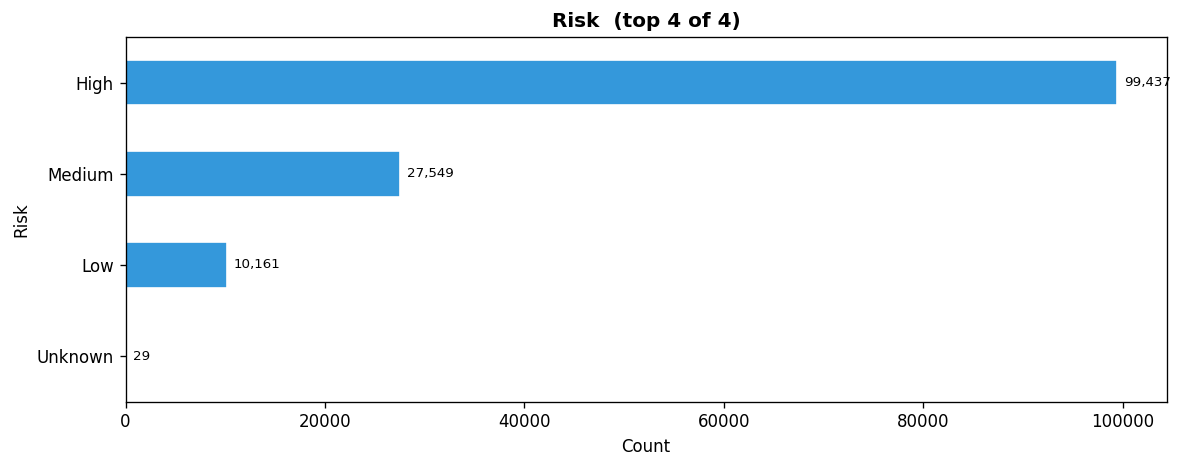

In [3]:
risk_vc = plot_categorical('Risk', top_n=10)

## 2 · Facility Type

── Facility Type ──
  Unique: 431  |  Null: 613 (0.4%)
  Categories with < 50 rows: 406  (94% of categories)


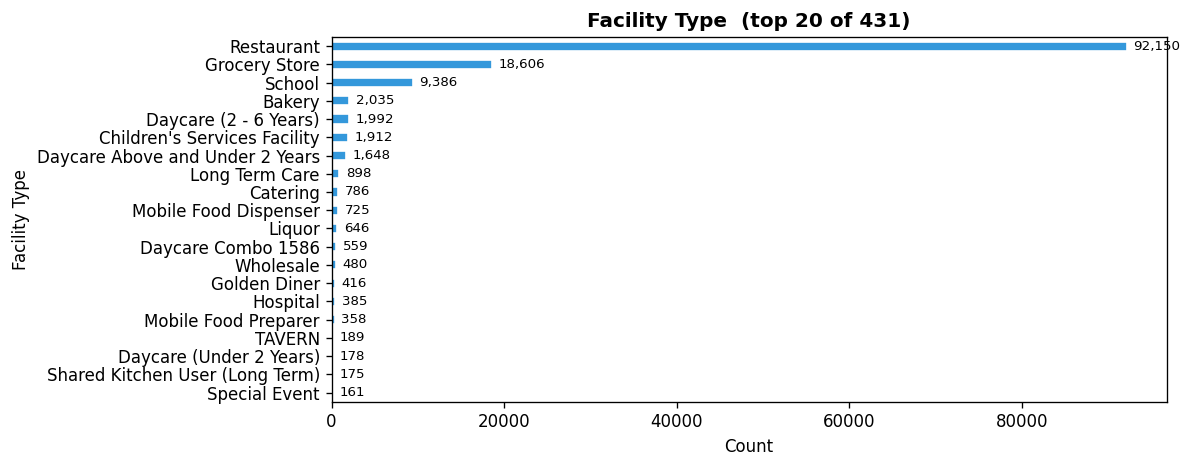

In [4]:
fac_vc = plot_categorical('Facility Type', top_n=20)

## 3 · Inspection Type

── Inspection Type ──
  Unique: 103  |  Null: 1 (0.0%)
  Categories with < 50 rows: 84  (82% of categories)


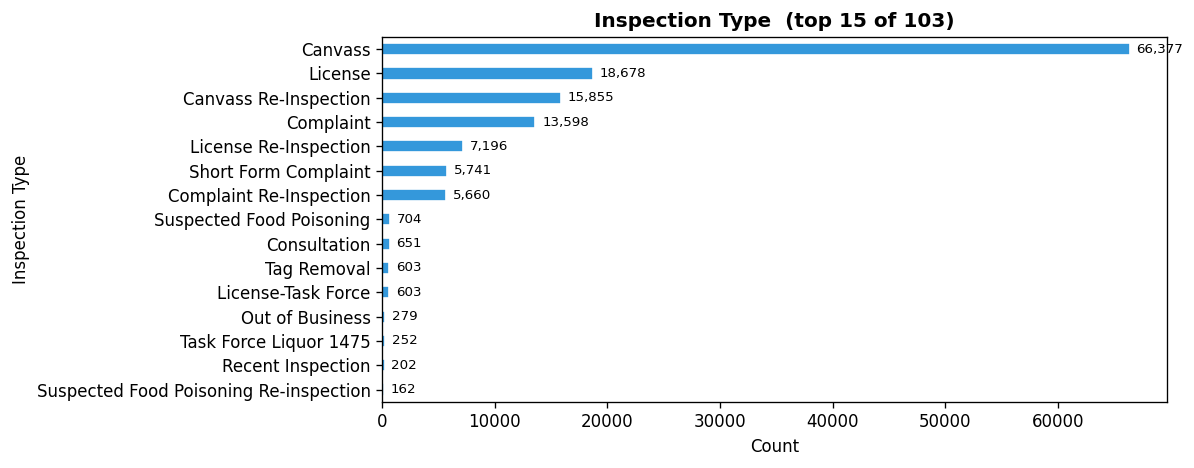

In [5]:
insp_vc = plot_categorical('Inspection Type', top_n=15)

## 4 · License fields

── LICENSE DESCRIPTION ──
  Unique: 63  |  Null: 6765 (4.9%)
  Categories with < 50 rows: 38  (60% of categories)


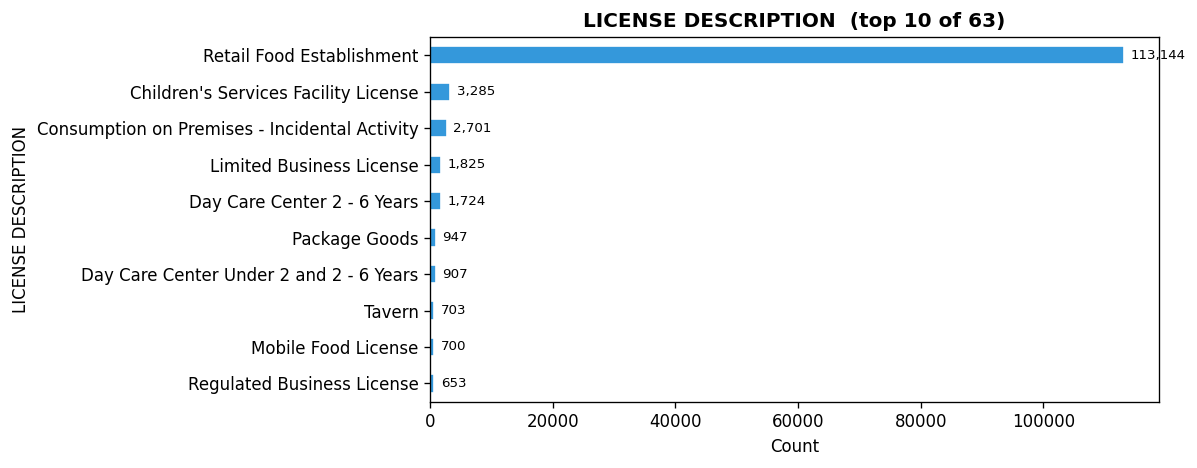


── LICENSE STATUS ──
  Unique: 4  |  Null: 6765 (4.9%)
  Categories with < 50 rows: 1  (25% of categories)


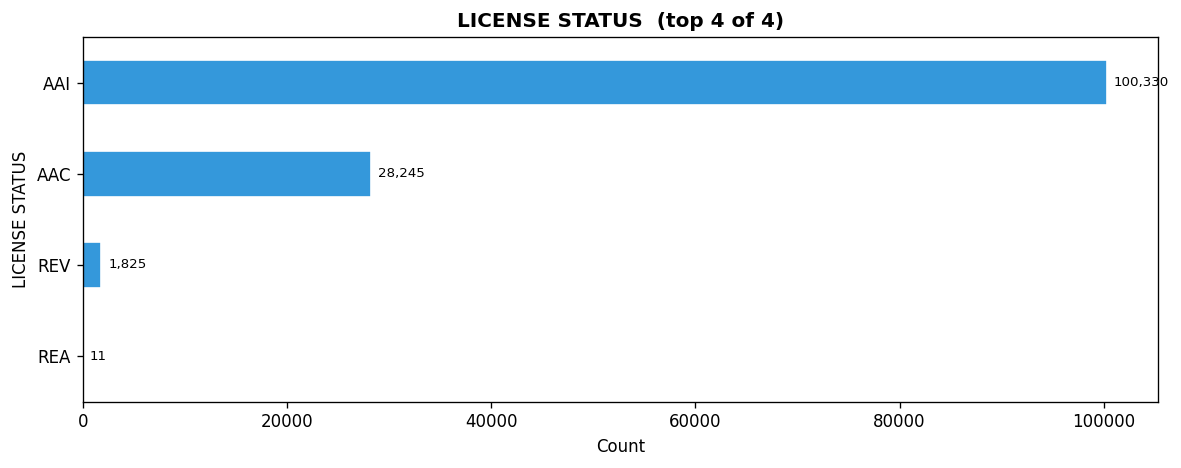


── APPLICATION TYPE ──
  Unique: 6  |  Null: 6765 (4.9%)
  Categories with < 50 rows: 1  (17% of categories)


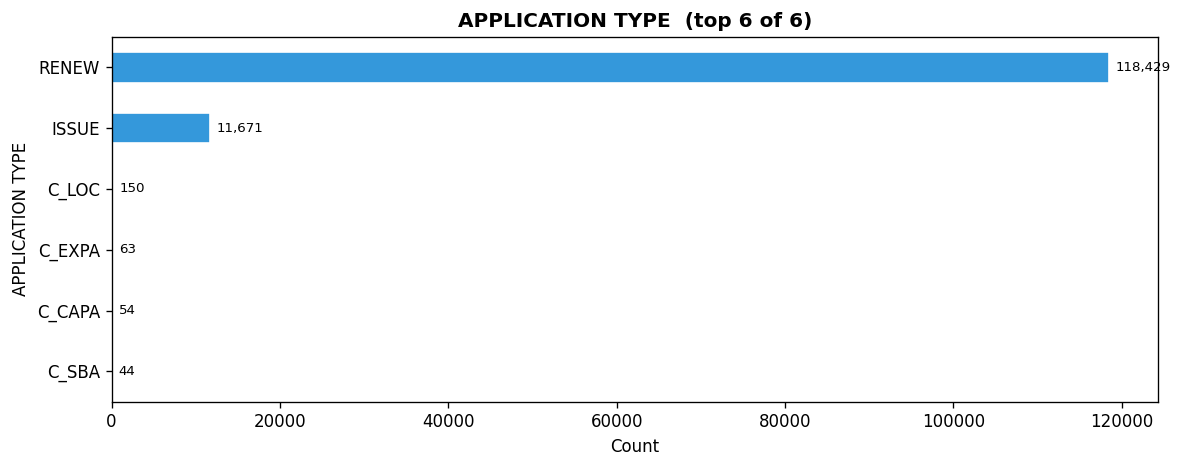

In [6]:
for col in ['LICENSE DESCRIPTION', 'LICENSE STATUS', 'APPLICATION TYPE']:
    if col in df.columns:
        plot_categorical(col, top_n=10)
        print()

## 5 · Community Area

── COMMUNITY AREA NAME ──
  Unique: 77  |  Null: 8133 (5.9%)
  Categories with < 50 rows: 2  (3% of categories)


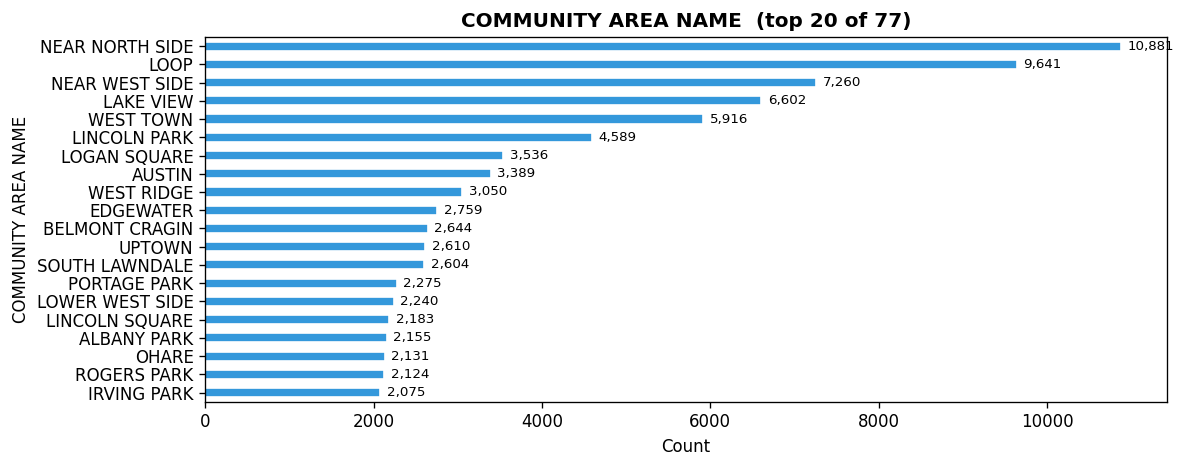

In [7]:
if 'COMMUNITY AREA NAME' in df.columns:
    ca_vc = plot_categorical('COMMUNITY AREA NAME', top_n=20)

## 6 · Boolean flags

Boolean flag summary:


,true_count,true_pct,false_count
flag_non_il_state,0,0.00,137176
flag_non_chicago_city,149,0.11,137027
flag_longitude_outside_typical_range,0,0.00,137176
violations_recorded,114101,83.18,23075
license_matched,0,0.00,137176
has_prior_inspection,110027,80.21,27149


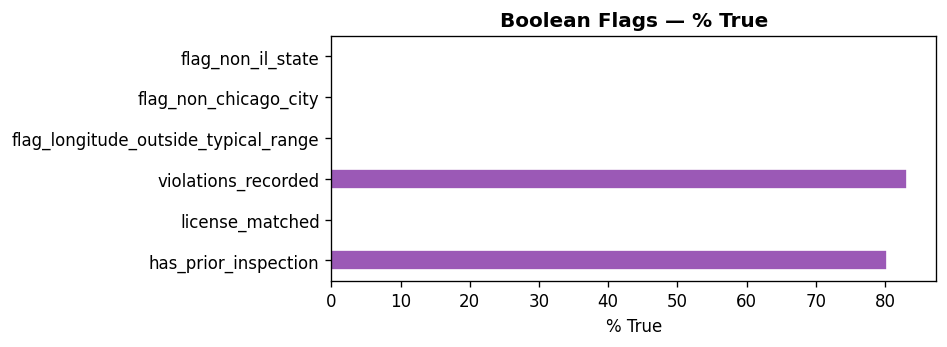

In [8]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    flag_summary = pd.DataFrame({
        'true_count': df[bool_cols].sum(),
        'true_pct': (df[bool_cols].mean() * 100).round(2),
        'false_count': (~df[bool_cols]).sum(),
    })
    print('Boolean flag summary:')
    display(flag_summary)

    fig, ax = plt.subplots(figsize=(8, 3))
    flag_summary['true_pct'].plot.barh(ax=ax, color=PALETTE[4], edgecolor='white')
    ax.set_title('Boolean Flags — % True', fontweight='bold')
    ax.set_xlabel('% True')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7 · Text columns (DBA Name, AKA Name, Address, Violations)

These are high-cardinality text fields. Quick stats only — detailed NLP
analysis of Violations should happen during feature engineering.

In [9]:
text_cols = ['DBA Name', 'AKA Name', 'Address', 'Violations']
text_cols = [c for c in text_cols if c in df.columns]

text_stats = pd.DataFrame({
    'nunique': [df[c].nunique() for c in text_cols],
    'null_pct': [(df[c].isna().mean() * 100) for c in text_cols],
    'avg_length': [df[c].dropna().astype(str).str.len().mean() for c in text_cols],
    'max_length': [df[c].dropna().astype(str).str.len().max() for c in text_cols],
}, index=text_cols).round(1)

text_stats

,nunique,null_pct,avg_length,max_length
DBA Name,20773,0.0,18.7,79
AKA Name,19826,1.2,18.0,79
Address,15766,0.0,17.6,39
Violations,113479,16.8,1191.7,11620
